In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import linregress

In [124]:
# Functions

def find_plateaus(time, data, window=500, poly=1, epsilon=0.001, gap_thresh=100):
    """
    Smooths data, calculates derivative, and groups indices into "plateaus".
    """
    # Savitzky-Golay for smoothing and 1st derivative
    deriv = savgol_filter(data, window, poly, deriv=1, delta=time[1]-time[0])
    
    # Identify indices where slope is near zero
    indices = np.where((deriv < epsilon) & (deriv > -epsilon))[0]
    
    # Grouping indices by gaps
    gaps = np.where(np.diff(indices) > gap_thresh)[0] + 1
    groups = np.split(indices, gaps)
    
    # Filter out tiny flickers (less than 10 points)
    groups = [g for g in groups if len(g) > 10]
    # Sort by time
    groups = sorted(groups, key=lambda x: time[x[0]])
    
    return deriv, indices, groups

def analyze_drift(time, data, groups):
    """
    Calculates the 'Micro-Slope' of each plateau to check for upward trends.
    """
    results = []
    for region in groups:
        t_part = time[region]
        d_part = data[region]
        slope, intercept, _, _, _ = linregress(t_part, d_part)
        results.append({
            'avg': np.mean(d_part),
            'slope': slope,
            'intercept': intercept,
            't_mid': (t_part[0] + t_part[-1]) / 2,
            't_range': (t_part[0], t_part[-1])
        })
    return results

def plot_thermal_results(time, grad, deriv, indices, plateau_info, 
                         inset_data=None, zoom_window=(4000, 10000), 
                         color='blue', title="Curve", label_data="Raw", ylabel_data=r"$\Delta$T [°C]"):
    """
    Creates the main plot with staggered labels and the requested inset.
    """
    fig, ax1 = plt.subplots(figsize=(14, 10))
    
    # Main Data
    ax1.plot(time, grad, color=color, label=label_data, lw=1.5, alpha=1)
    #ax1.scatter(time[indices], grad[indices], color='green', s=2, label='Steady State')

    # Staggered Labeling with Drift (Trend) Lines
    height_levels = [15, 35, 55, 75]
    for i, p in enumerate(plateau_info):
        # Draw the actual "Fitted" trend line instead of a flat hline
        t_line = np.array(p['t_range'])
        y_line = p['slope'] * t_line + p['intercept']
        ax1.plot(t_line, y_line, color='black', lw=2.5, zorder=5)
        
        # Labeling
        offset = height_levels[i % len(height_levels)]
        # We show the average and the drift rate
        label_text = f"{p['avg']:.2f} °C\nSlope: {p['slope']:.2e}"
        
        ax1.annotate(
            label_text, xy=(p['t_mid'], p['avg']), xytext=(0, offset),
            textcoords="offset points", ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='red',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8),
            arrowprops=dict(arrowstyle='-', color='red', alpha=0.3)
        )

    # Inset Logic
    if inset_data is not None:
        # [left, bottom, width, height] as fractions
        ax_ins = ax1.inset_axes([0.5, 0.6, 0.45, 0.35])
        
        # Plot Immersion (from your provided tuple/dict)
        imm_t, imm_v = inset_data['immersion']
        ax_ins.plot(imm_t, imm_v, color='blue', lw=1, label='Immersion')
        ax_ins.set_ylabel("Depth [mm]", color='blue', fontsize=8)
        
        # Twin for Furnace Temp
        ax_ins2 = ax_ins.twinx()
        fur_t, fur_v = inset_data['furnace']
        ax_ins2.plot(fur_t, fur_v, color='magenta', lw=1)
        ax_ins2.set_ylabel("Furnace [°C]", color='magenta', fontsize=8)
        
        ax_ins.set_xlim(zoom_window)
        ax_ins.set_title("Immersion & Furnace Profile", fontsize=9, fontweight='bold')
        ax_ins.grid(True, alpha=0.2)

    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel(ylabel_data)
    ax1.set_title(title, fontweight='bold')
    ax1.legend(loc='lower left')
    plt.show()

    

In [49]:

def generate_experiment_report(time, grad, furnace_data, immersion_data, 
                               plateau_info, params):
    """
    Creates a 3-panel vertical dashboard:
    1. Salt Plateaus with Staggered Labels
    2. Furnace Temperature Profile (The 'Heating' Context)
    3. Immersion Depth (The 'Physical' Context)
    """
    # sharex=True is CRITICAL: Zooming in on one panel zooms the others!
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15), sharex=True, 
                                       gridspec_kw={'height_ratios': [2, 1, 1]})

    # --- PANEL 1: SALT GRADIENT & PLATEAUS ---
    ax1.plot(time, grad, color='darkgray', lw=1, alpha=0.5, label='Salt Gradient')
    
    # Labeling Logic (using the plateau_info from the previous function)
    height_levels = [20, 45, 70, 95]
    for i, p in enumerate(plateau_info):
        # Draw the Plateau Line
        t_line = np.array(p['t_range'])
        y_line = p['slope'] * t_line + p['intercept']
        ax1.plot(t_line, y_line, color='red', lw=3)
        
        # Staggered Annotation
        ax1.annotate(f"{p['avg']:.2f} °C", xy=(p['t_mid'], p['avg']), 
                     xytext=(0, height_levels[i % 4]), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.7),
                     arrowprops=dict(arrowstyle='-', color='red', alpha=0.3))

    ax1.set_ylabel(r"$\Delta$T [°C]")
    ax1.set_title(f"Experiment Summary: w={params['w']}, $\epsilon$={params['e']}", fontweight='bold')
    ax1.legend(loc='upper left')

    # --- PANEL 2: FURNACE PROFILE ---
    # Plotting the furnace temps (using its specific time array)
    ax2.plot(furnace_data[0], furnace_data[1], color='magenta', lw=1.5)
    # Shading the furnace region to make it look like a 'background'
    ax2.fill_between(furnace_data[0], furnace_data[1], color='magenta', alpha=0.1)
    ax2.set_ylabel("Furnace [°C]", color='magenta', fontweight='bold')
    ax2.grid(True, alpha=0.2)

    # --- PANEL 3: IMMERSION PROFILE ---
    ax3.plot(immersion_data[0], immersion_data[1], color='blue', lw=1.5)
    ax3.set_ylabel("Depth [mm]", color='blue', fontweight='bold')
    ax3.set_xlabel("Time [s]")
    ax3.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    
def plot_salt_channels(time, channels, title="Salt Temperature Channels"):
    """
    Plots multiple salt channels on one clean graph.
    'channels' should be a list of arrays: [ch1, ch2, ch3, ch4]
    """
    plt.figure(figsize=(12, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Standard distinct colors
    
    for i, ch_data in enumerate(channels):
        plt.plot(time, ch_data, label=f"Channel {i+1}", color=colors[i], lw=1, alpha=0.8)
    
    plt.title(title, fontweight='bold')
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature [°C]")
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.2)
    plt.show()


<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
C:\Users\jeanv\AppData\Local\Temp\ipykernel_17372\3462341401.py:32: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_title(f"Experiment Summary: w={params['w']}, $\epsilon$={params['e']}", fontweight='bold')


In [50]:
Path = r"C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Experiments\nic\temperature_measurements"

# Loading data from the text files
dataRun2 = np.loadtxt(Path + r"\Round2_copy.txt", delimiter="\t")
dataRun1 = np.loadtxt(Path + r"\Round1_copy.txt", delimiter="\t")
dataRun1_75015mm = np.loadtxt(Path + r"\15mm750C_run1_copy.txt", delimiter="\t")
dataRun3_part1 = np.loadtxt(Path + r"\Round3_part1.txt", delimiter="\t")
dataRun3_part2 = np.loadtxt(Path + r"\Round3_part2.txt", delimiter="\t")

In [95]:
timerun2 = dataRun2[:, 0]  # Time in [s]
CH0run2 = dataRun2[:, 1]   # Channel 0: Cold salt temperature in [°C]
CH1run2 = dataRun2[:, 2]   # Channel 1: Hot salt temperature in [°C]
CH2run2 = dataRun2[:, 3]   # Channel 2: Cold outer temperature in [°C] (called Copper Temp)
CH3run2 = dataRun2[:, 4]   # Channel 3: Hot outer temperature in [°C] (called Alumina Temp)

timerun1 = dataRun1[:, 0]
CH0run1 = dataRun1[:, 1]
CH1run1 = dataRun1[:, 2]
CH2run1 = dataRun1[:, 3]
CH3run1 = dataRun1[:, 4]

timerun1_75015mm = dataRun1_75015mm[:, 0]
CH0run1_75015mm = dataRun1_75015mm[:, 1]
CH1run1_75015mm = dataRun1_75015mm[:, 2]
CH2run1_75015mm = dataRun1_75015mm[:, 3]
CH3run1_75015mm = dataRun1_75015mm[:, 4]


timerun3_part1 = dataRun3_part1[:, 0]
CH0run3_part1 = dataRun3_part1[:, 1]
CH1run3_part1 = dataRun3_part1[:, 2]
CH2run3_part1 = dataRun3_part1[:, 3]
CH3run3_part1 = dataRun3_part1[:, 4]

timerun3_part2 = dataRun3_part2[:, 0]
CH0run3_part2 = dataRun3_part2[:, 1]
CH1run3_part2 = dataRun3_part2[:, 2]
CH2run3_part2 = dataRun3_part2[:, 3]
CH3run3_part2 = dataRun3_part2[:, 4]

timerun3 = np.concatenate((timerun3_part1, timerun3_part2+timerun3_part1[-1]))
CH0run3 = np.concatenate((CH0run3_part1, CH0run3_part2))
CH1run3 = np.concatenate((CH1run3_part1, CH1run3_part2))
CH2run3 = np.concatenate((CH2run3_part1, CH2run3_part2))
CH3run3 = np.concatenate((CH3run3_part1, CH3run3_part2))

## Events occuring doing operation
events_run2 = [
    (2100, "Melting event"),
    (2358, r"5V cooling"),
    (2690, r"8V cooling"),
    (2800, r"12V cooling"),
    (3100, r"$\uparrow$ Argon flow"),
    (4600, r"$\downarrow$ 7 [mm]"),
    (5600, r"$\downarrow$ Argon flow"),
    (6000, r"$\downarrow$ 5 [mm]"),
    (7000, r"$\downarrow$ 10 [mm]"),

    (7200, r"$T_{f} = 900 [°C]$"),
    (7700, r"$\uparrow$ Argon flow"),
    (8000, r"$14V$ cooling"),
    (8500, r"$\downarrow$ 10 [mm]"),
    (8750, r"$T_{f} = 1000 [°C]$")]



# 1. Define your conditions (The Time Intervals)
# You can add as many as you want here
conditions_furnace_run2 = [
    (timerun2 >= 0)    & (timerun2 < 7500),   # Pre-heating/Start
    (timerun2 >= 7500) & (timerun2 < 8500),   # First Plateau (750C)
    (timerun2 >= 8500) & (timerun2 < 10000),   # Second Plateau (900C)
    (timerun2 >= 10000)                       # Final Plateau (1000C)
]

conditions_furnace_run3 = [
    (timerun3 >= 0)    & (timerun3 < 6860),   # Pre-heating/Start
    (timerun3 >= 6860) &    (timerun3 < 10600),   # First Plateau (750C)
    (timerun3 >= 10600) &    (timerun3 < 11880),   # Second Plateau (900C)
    (timerun3 >= 11880) &    (timerun3 < 19000),   # Final Plateau (1000C)
    (timerun3 >= 19000) &    (timerun3 < 20000),
    (timerun3 >= 20000) & (timerun3 < 21000),
    (timerun3 >= 21000) & (timerun3 < 22000),
    (timerun3 >= 22000)                       # Final Plateau (1000C)
]

conditions_immersion_run2 = [
    (timerun2 >= 0)    & (timerun2 < 4600),   # Pre-heating/Start
    (timerun2 >= 4600) & (timerun2 < 6000),   # First Plateau (750C)
    (timerun2 >= 6000) & (timerun2 < 7000),   # Second Plateau (900C)
    (timerun2 >= 7000) & (timerun2 < 8500),   # Third Plateau (1000C)
    (timerun2 >= 8500)                    # Final Plateau (1000C)
]

conditions_immersion_run3 = [
    (timerun3 >= 0)    & (timerun3 < 10600),   # Pre-heating/Start
    (timerun3 >= 10600)   # First Plateau (750C)
                     # Final Plateau (1000C)
]

# 2. Define the Temperature values for those intervals
values_furnace_run2 = [
    750,    # Room Temp
    900,   # 15mm Immersion Step
    1000,   # 1000C Step
    1000,

]

values_immersion_run2 = [
    -15,    # Room Temp
    -22,   # 15mm Immersion Step
    -27,   # 1000C Step
    -37,
    -47, 
]

values_furnace_run3 = [
    650,    # Room Temp
    700,   # 15mm Immersion Step
    750,   # 1000C Step
    800,
    875,
    950, 
    1000,
    1000,
]

values_immersion_run3 = [
    -52,
    -52,
]


# 3. Create the 1D temperature array
furnace_temps_run3 = np.select(conditions_furnace_run3, values_furnace_run3, default=0)
furnace_temps_run2 = np.select(conditions_furnace_run2, values_furnace_run2, default=0)
immersion_depths_run3 = np.select(conditions_immersion_run3, values_immersion_run3, default=0)
immersion_depths_run2 = np.select(conditions_immersion_run2, values_immersion_run2, default=0)

# 4. Combine into your (N, 2) array for your plotter
furnaceTemperatureTime_run2 = np.column_stack((timerun2, furnace_temps_run2))
furnaceTemperatureTime_run3 = np.column_stack((timerun3, furnace_temps_run3))
furnaceImmersionTime_run2 = np.column_stack((timerun2, immersion_depths_run2))
furnaceImmersionTime_run3 = np.column_stack((timerun3, immersion_depths_run3))


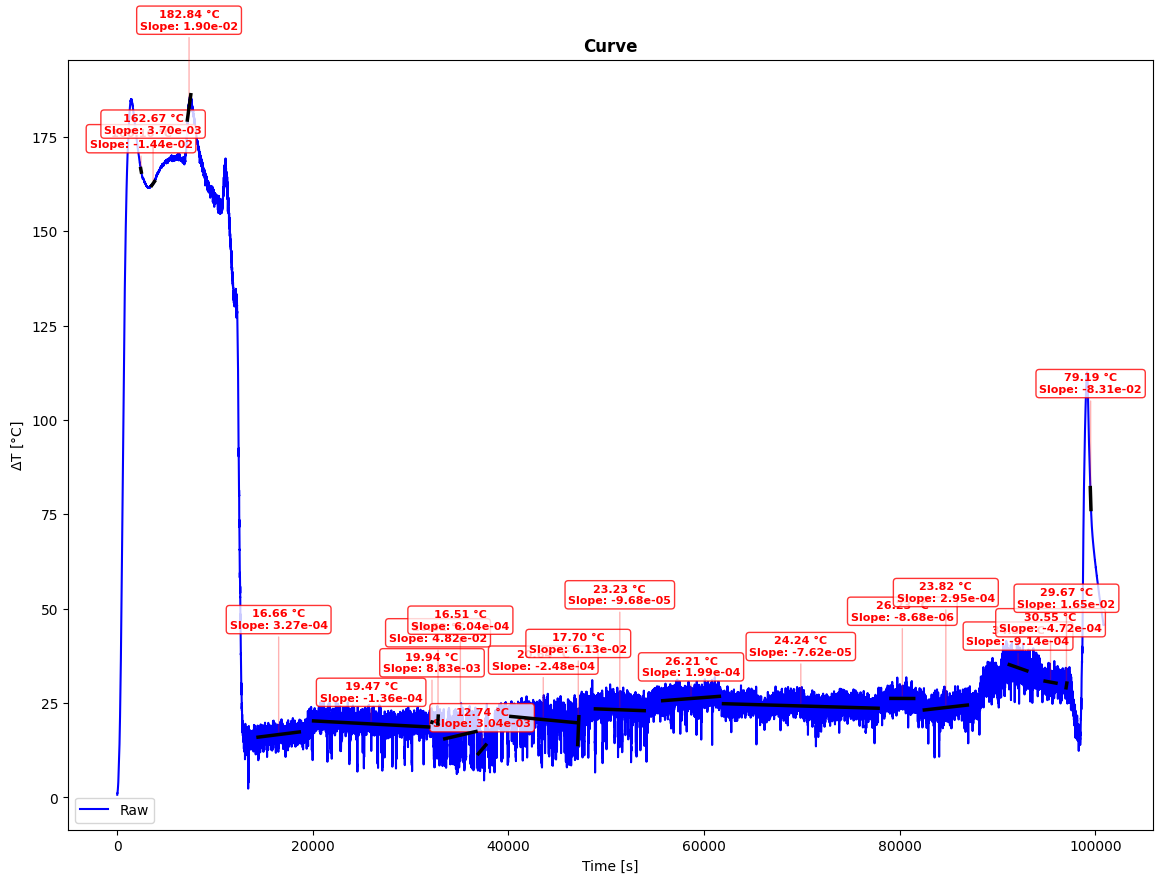

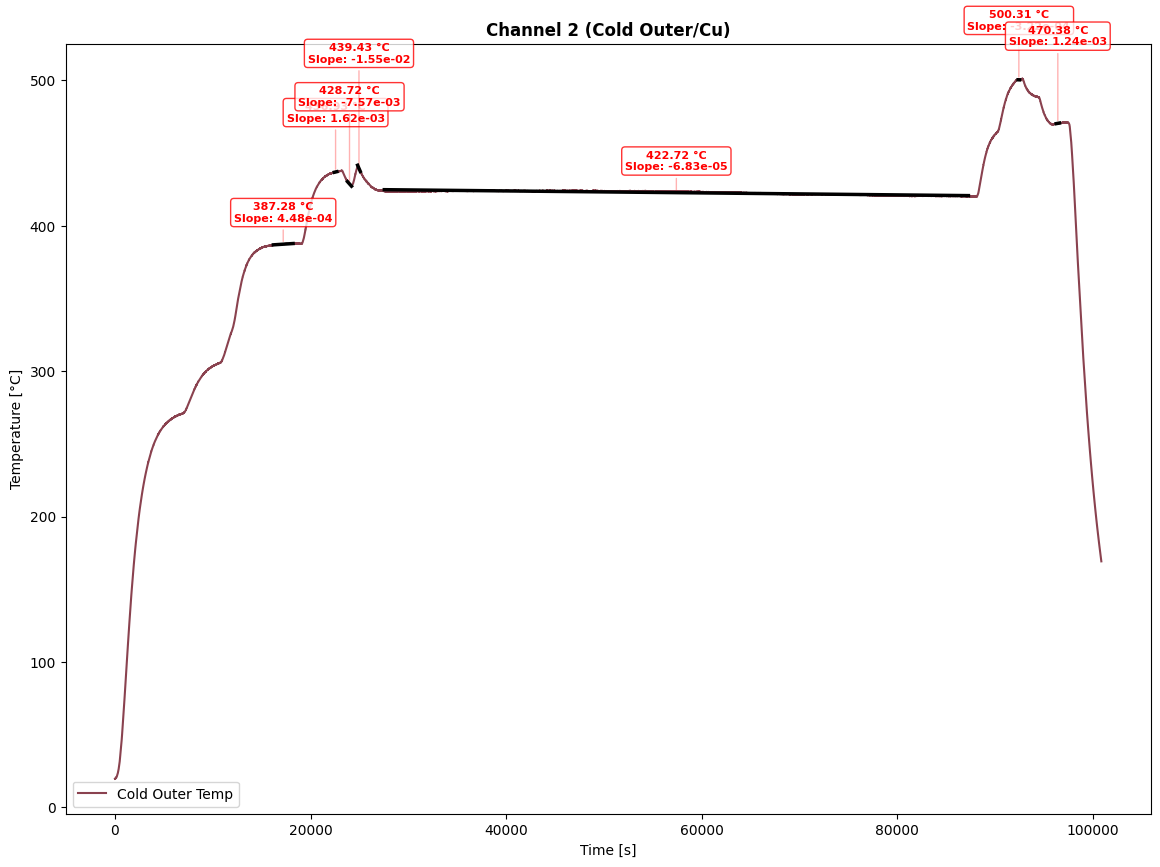

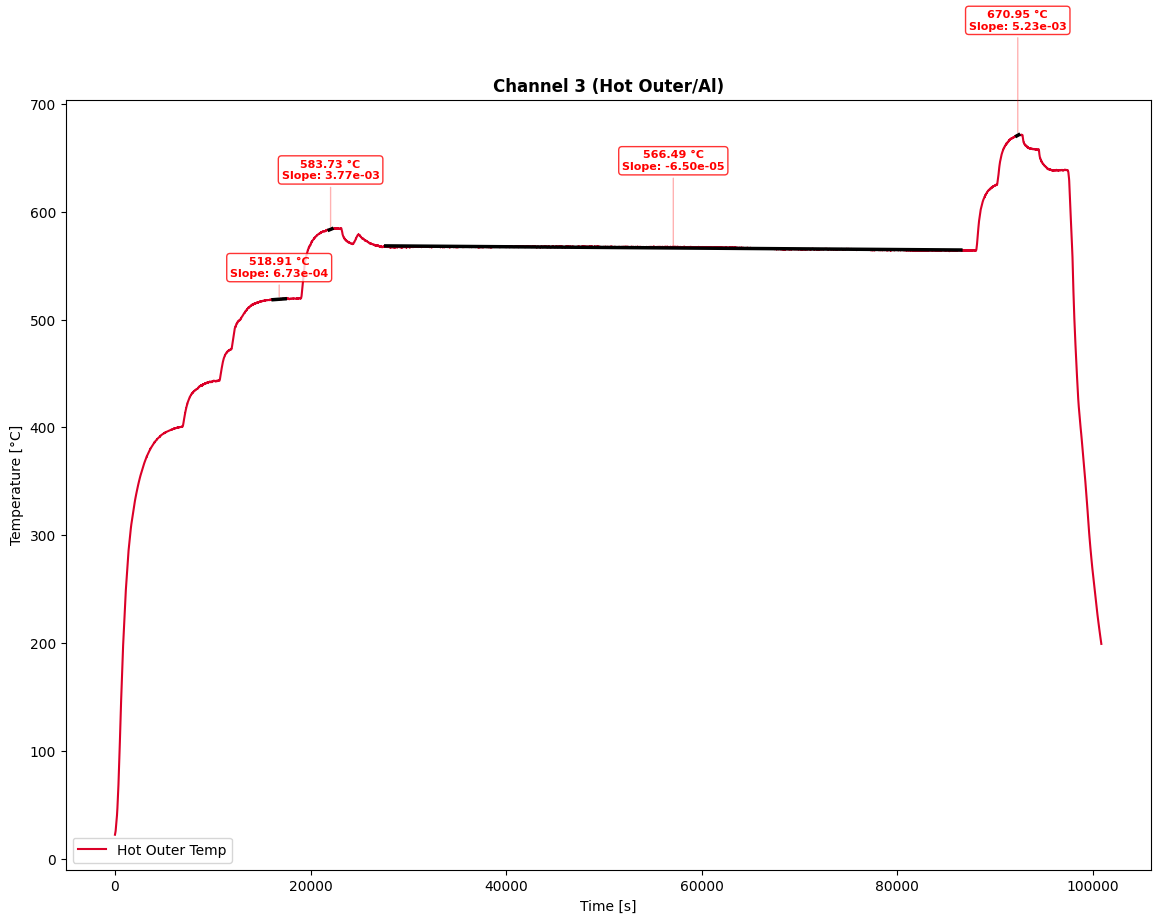

In [135]:
grad = CH1run3 - CH0run3  # Assuming Channel 1 is hot salt and Channel 0 is cold salt

WINDOW = 3000
EPSILON = 0.001
ZOOM = (60000, 90000)
POLY = 2


grad_deriv, plateau_idxs, groups = find_plateaus(timerun3, grad, window=WINDOW, poly=POLY, epsilon=EPSILON)
ch2run3_deriv, plateau_idxs_ch2, groups_ch2 = find_plateaus(timerun3, CH2run3, window=2000, poly=POLY, epsilon=EPSILON)
ch3run3_deriv, plateau_idxs_ch3, groups_ch3 = find_plateaus(timerun3, CH3run3, window=3000, poly=POLY, epsilon=EPSILON)
ch1run3_deriv, plateau_idxs_ch1, groups_ch1 = find_plateaus(timerun3, CH1run3, window=WINDOW, poly=POLY, epsilon=EPSILON)
ch0run3_deriv, plateau_idxs_ch0, groups_ch0 = find_plateaus(timerun3, CH0run3, window=WINDOW, poly=POLY, epsilon=EPSILON)

plateau_stats_grad = analyze_drift(timerun3, grad, groups)
plateau_stats_ch2 = analyze_drift(timerun3, CH2run3, groups_ch2)
plateau_stats_ch3 = analyze_drift(timerun3, CH3run3, groups_ch3)
plateau_stats_ch1 = analyze_drift(timerun3, CH1run3, groups_ch1)
plateau_stats_ch0 = analyze_drift(timerun3, CH0run3, groups_ch0)



# Prepare Inset Data
extra_data = {
    'immersion': (furnaceImmersionTime_run3[:, 0], furnaceImmersionTime_run3[:, 1]),
    'furnace': (furnaceTemperatureTime_run3[:, 0], furnaceTemperatureTime_run3[:, 1])
}

# Plot
plot_thermal_results(timerun3, grad, grad_deriv, plateau_idxs, plateau_stats_grad, 
                     inset_data=None, zoom_window=ZOOM)
plot_thermal_results(timerun3, CH2run3, ch2run3_deriv, plateau_idxs_ch2, plateau_stats_ch2,
                     inset_data=None, zoom_window=ZOOM, color="#8A424F", 
                     title="Channel 2 (Cold Outer/Cu)", label_data="Cold Outer Temp",
                     ylabel_data="Temperature [°C]")
plot_thermal_results(timerun3, CH3run3, ch3run3_deriv, plateau_idxs_ch3, plateau_stats_ch3,
                     inset_data=None, zoom_window=ZOOM, color="#DB0028", title="Channel 3 (Hot Outer/Al)", label_data="Hot Outer Temp",
                     ylabel_data="Temperature [°C]")

83775 83775 73075 83775


ValueError: x and y must have same first dimension, but have shapes (73075,) and (83775,)

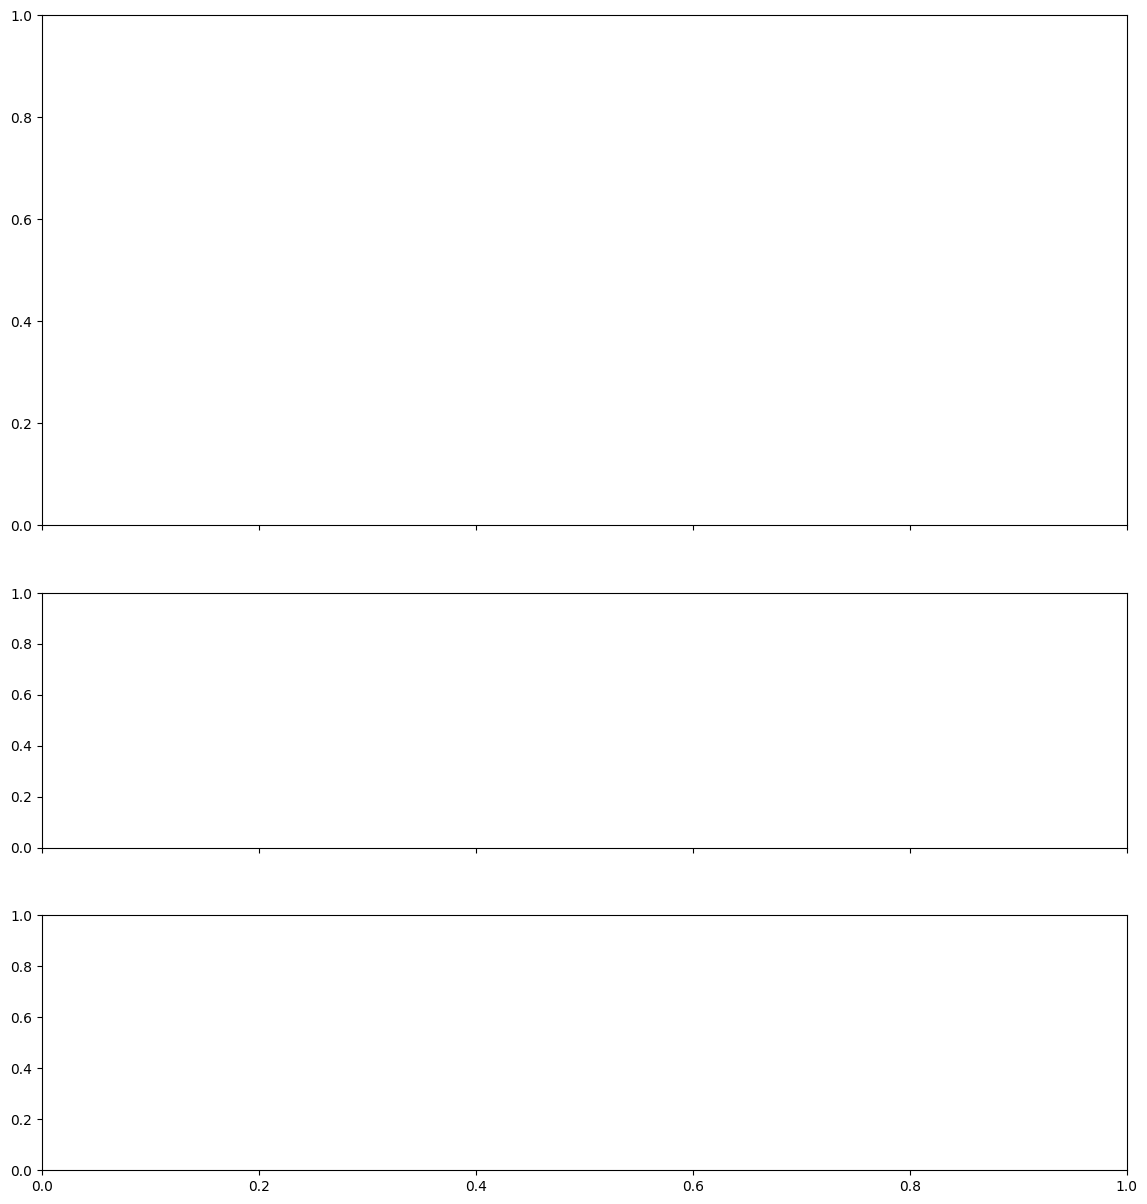

In [125]:


# 1. Setup your parameters
analysis_params = {'w': 501, 'p': 1, 'e': 0.001}

# 2. Run the plateau finding (from the previous step)
# deriv, idxs, groups = find_plateaus(...)
# plateau_stats = analyze_drift(...)

# 3. Compile the "profiles" into simple tuples (time, value)
furnace_profile = (furnaceTemperatureTime_run3[:, 0], furnaceTemperatureTime_run3[:, 1])
immersion_profile = (furnaceImmersionTime_run3[:, 0], furnaceImmersionTime_run3[:, 1])

print(len(furnace_profile[0]), len(immersion_profile[0]), len(timerun3_part1), len(grad))

# 4. Generate the massive report
generate_experiment_report(timerun3_part1, grad, furnace_profile, immersion_profile, 
                           plateau_stats, analysis_params)

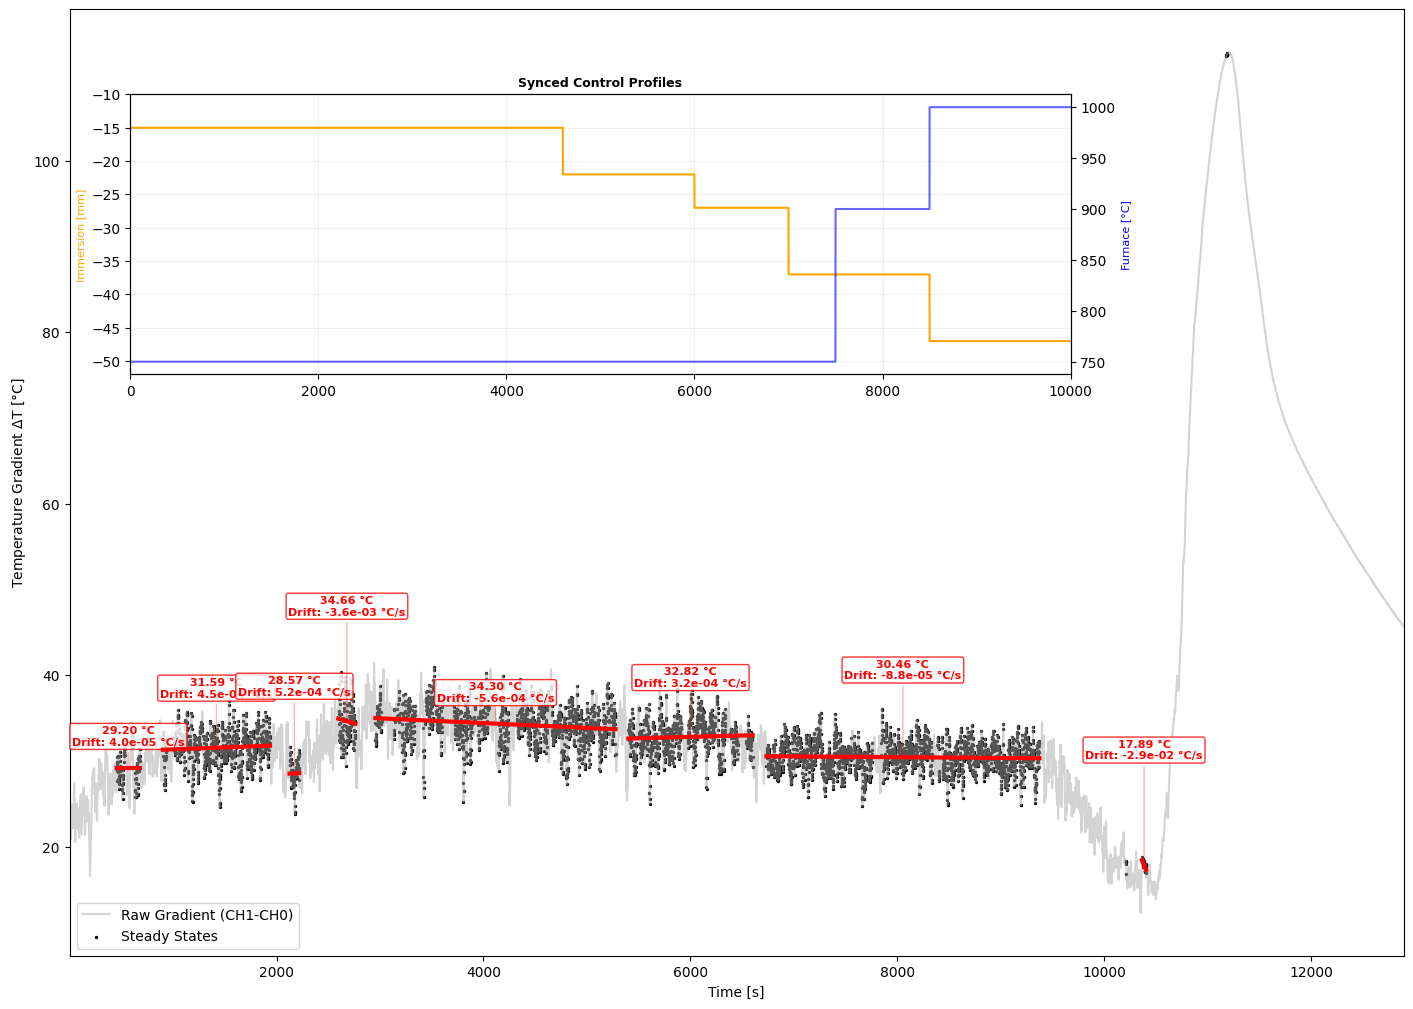

In [82]:

# --- 1. SETTINGS & STYLING ---
COLORS = ['#2E5C36', '#00DB27', '#8A424F', '#DB0028']
LABELS = [
    "Upper salt (Cold salt)", 
    "Lower salt (Hot salt)", 
    "Upper crucible (Outer cold)", 
    "Lower crucible (Outer hot)"
]

# --- 2. ANALYSIS FUNCTIONS ---
def get_plateaus(time, data, window=501, poly=1, epsilon=0.001, gap_thresh=100):
    deriv = savgol_filter(data, window, poly, deriv=1, delta=np.mean(np.diff(time)))
    indices = np.where((deriv < epsilon) & (deriv > -epsilon))[0]
    gaps = np.where(np.diff(indices) > gap_thresh)[0] + 1
    groups = [g for g in np.split(indices, gaps) if len(g) > 10]
    
    stats = []
    for region in groups:
        t_p, d_p = time[region], data[region]
        slope, intercept, _, p_val, _ = linregress(t_p, d_p)
        stats.append({
            'avg': np.mean(d_p), 'slope': slope, 'intercept': intercept,
            't_range': (t_p[0], t_p[-1]), 't_mid': (t_p[0] + t_p[-1]) / 2,
            'significant': p_val < 0.05
        })
    return deriv, indices, stats

# --- 3. PLOTTING TOOLS ---
def plot_all_channels(time, channels, title="Thermal Profile Overview"):
    plt.figure(figsize=(12, 6))
    for i, ch_data in enumerate(channels):
        plt.plot(time, ch_data, color=COLORS[i], label=LABELS[i], lw=1.2)
    plt.title(title, fontweight='bold')
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature [°C]")
    plt.grid(True, alpha=0.2)
    plt.legend(loc='lower right', fontsize=8, ncol=2)
    plt.show()

def plot_final_dashboard(time, grad, deriv, indices, plateau_stats, 
                         furnace_data, immersion_data, zoom=(4000, 10700)):
    fig, ax1 = plt.subplots(figsize=(14, 10))
    
    # Main Plot (Gradient)
    ax1.plot(time, grad, color='darkgray', alpha=0.5, label='Raw Gradient (CH1-CH0)')
    ax1.scatter(time[indices], grad[indices], color='black', s=2, label='Steady States')

    # Draw and Label Plateaus
    heights = [15, 35, 55, 75]
    for i, p in enumerate(plateau_stats):
        t_l = np.array(p['t_range'])
        y_l = p['slope'] * t_l + p['intercept']
        ax1.plot(t_l, y_l, color='red', lw=3, zorder=5)
        drift_label = f"{p['avg']:.2f} °C\nDrift: {p['slope']:.1e} °C/s"
        ax1.annotate(drift_label, xy=(p['t_mid'], p['avg']), 
                     xytext=(0, heights[i % 4]), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8, fontweight='bold', color='red',
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.8),
                     arrowprops=dict(arrowstyle='-', color='red', alpha=0.3))

    # --- SYNCED INSET CALCULATION ---
    # We force a draw to get the physical position of the main axis
    plt.tight_layout()
    fig.canvas.draw()
    main_pos = ax1.get_position() # [x0, y0, width, height]
    
    # Find fractions of the x-axis that the zoom window covers
    x_min, x_max = ax1.get_xlim()
    x_total = x_max - x_min
    frac_left = (zoom[0] - x_min) / x_total
    frac_width = (zoom[1] - zoom[0]) / x_total
    
    # Calculate physical coordinates for the inset to align perfectly with the x-axis
    inset_x = main_pos.x0 + (frac_left * main_pos.width)
    inset_w = frac_width * main_pos.width
    
    # Create the synced inset axis
    # [left, bottom, width, height]
    ax_ins = fig.add_axes([inset_x, 0.62, inset_w, 0.28])
    
    # Plot Inset Data
    ax_ins.plot(immersion_data[:, 0], immersion_data[:, 1], color='orange', label='Immersion')
    ax_ins_f = ax_ins.twinx()
    ax_ins_f.plot(furnace_data[:, 0], furnace_data[:, 1], color='blue', alpha=0.6)
    
    ax_ins.set_xlim(zoom)
    ax_ins.set_ylim(np.min(immersion_data[:,1])-5, np.max(immersion_data[:,1])+5)
    ax_ins.set_title("Synced Control Profiles", fontsize=9, fontweight='bold')
    ax_ins.set_ylabel("Immersion [mm]", color='orange', fontsize=8)
    ax_ins_f.set_ylabel("Furnace [°C]", color='blue', fontsize=8)
    ax_ins.grid(True, alpha=0.2)

    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel(r"Temperature Gradient $\Delta$T [°C]")
    ax1.set_xlim(time[0], time[-1])
    ax1.legend(loc='lower left')
    plt.show()

# --- 4. EXECUTION ---
W_LEN = 300
EPS = 0.005
ZOOM_WINDOW = (0, 10000)

main_grad = CH1run3_part2 - CH0run3_part2
deriv_data, ss_indices, plateau_info = get_plateaus(timerun3_part2, main_grad, window=W_LEN, epsilon=EPS)

#plot_all_channels(timerun3_part1, [CH0run3_part1, CH1run3_part1, CH2run3_part1, CH3run3_part1])
plot_final_dashboard(timerun3_part2, main_grad, deriv_data, ss_indices, plateau_info,
                     furnaceTemperatureTime_run2, furnaceImmersionTime_run2, 
                     zoom=ZOOM_WINDOW)